# **Lab 01 - Introduction to Python, Gymnasium and Formulating RL Problem**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 1: Getting familiar with Gymnasium

In [1]:
# import Gymnasium library and alias as gym
import gymnasium as gym

In [7]:
def action_space (velocity):
    if velocity < 0:
        return 0
    else: return 2

In [7]:
total_reward = 0
truncated = False
done = False

In [18]:
# Create the MountainCar-v0 environment and reset to obtain the initial observation
### YOU NEED TO WRITE YOUR CODE BELOW ###
# HERE 
env = gym.make("MountainCar-v0", render_mode= "human")
observation, _ = env.reset(seed = 2026)


In [ ]:

while not done and not truncated:

    # Define action by sampling randomly from the environment action space
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    action = action_space(observation[1])

    # Execute the action
    # HERE
    new_obs, reward, done, truncated, info = env.step(action)
    
    total_reward += reward
    observation = new_obs
    env.render()

print("Reward: {}".format(total_reward))
env.close()

Reward: -114.0


## Part 2: Custom Environment "VacuumCleaner"

In [2]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)

import matplotlib.pyplot as plt
import numpy as np
import os
import time
from IPython.display import clear_output

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2)):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)

        # Action space: 0=up, 1=down, 2=left, 3=right
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        # Thiết lập không gian action cho agent là 4 (0, 1, 2, 3)
        self.action_space = gym.spaces.Discrete(4)

        # Observation space: position and dust grid
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        # Thiết lập không gian giám sát của env là vị trí của robot và ma trận bụi
        # Với vị trí chỉ gồm 2 phần tử có giá trị là số nguyên rời rạc từ 0 -> max(m-1, n-1)
        # Với bụi là một ma trận mxn phần tử có giá trị là số nguyên rời rạc từ 0 -> 1
        self.observation_space = gym.spaces.Dict({
            'position': gym.spaces.Box(low=0, high=max(m-1,n-1), shape=(2,), dtype = np.int32),
            'dust': gym.spaces.Box(low=0, high=1, shape=(m,n), dtype=np.int32)
        })

        self.reset()

    def reset(self, *, seed=None, options=None):
        # initialize position and dust
        # Start the robot at the top-left corner (row 0, column 0)
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        # Tạo ra mảng có 2 phần tử bằng thư viện Numpy
        self.position = np.array([0,0])

        # Initialize dust grid: 1 indicates dirty, 0 indicates clean.
        # Shape is (m, n) corresponding to the room dimensions.
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        # Tạo ra ma trận mxn với tất cả các phần tử đều bằng 1 bằng thư viện Numpy
        self.dust_grid = np.ones((self.m, self.n))

        # Ensure the obstacle cell contains no dust (robot cannot clean there).
        # This also prevents rewarding the agent for occupying the obstacle.
        self.dust_grid[self.obstacle] = 0  # obstacle cell has no dust
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False
        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, {}

    def step(self, action):
        # compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        if action == 0:   # Up
            candidate = [self.position[0] - 1, self.position[1]]
        elif action == 1: # Down
            candidate = [self.position[0] + 1, self.position[1]]
        elif action == 2: # Left
            candidate = [self.position[0], self.position[1] - 1]
        elif action == 3: # Right
            candidate = [self.position[0], self.position[1] + 1]
        else:
            candidate = self.position.copy()

        # boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()
                reward = -10.0
                self.terminated = True
                obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
                self.total_reward += reward
                return obs, reward, True, False, {}
            else:
                self.position = candidate.copy()
        # else: stay in place

        # If the robot is on a dirty cell, give a positive reward (1.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        if self.dust_grid[self.position[0], self.position[1]] == 1:
            reward = 1
            self.dust_grid[self.position[0], self.position[1]] = 0
        else: reward = -0.5

        self.total_reward += reward

        # check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 10.0
            self.total_reward += 10
            self.terminated = True

        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, reward, bool(self.terminated), bool(self.truncated), {}

    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)

In [4]:
def robot_policy_1(option="random", env=None):
     """
     A simple policy function that selects an action based on the specified option.
     Currently supports only a random policy.
     """
     return env.action_space.sample()  # Randomly select an action from the action space
    
def robot_policy_2 (option="round_robin", env=None):
     x, y = env.position
     # m = env.m
     n = env.n
     # Right
     if x % 2 == 0 and y < n - 1:
          return 3
     # Down
     elif x % 2 == 0 and y == n - 1:
          return 1
     # Left
     elif x % 2 == 1 and y > 0:
          return 2
     # Down
     else: return 1

def robot_policy_3 (option="priority_based", head=0, below=0, left=0, right=0, action=3, env=None):
     x, y = env.position
     # Right
     if action == 3:
          if y == right:
               # Down
               action = 1
               head += 1
     # Down
     elif action == 1:
          if x == below:
               # Left
               action = 2
               right -= 1
     # Left
     elif action == 2:
          if y == left:
               # Up
               action = 0
               below -= 1
     elif action == 0:
          if x == head:
               action = 3
               left += 1
     return head, below, left, right, action     
     

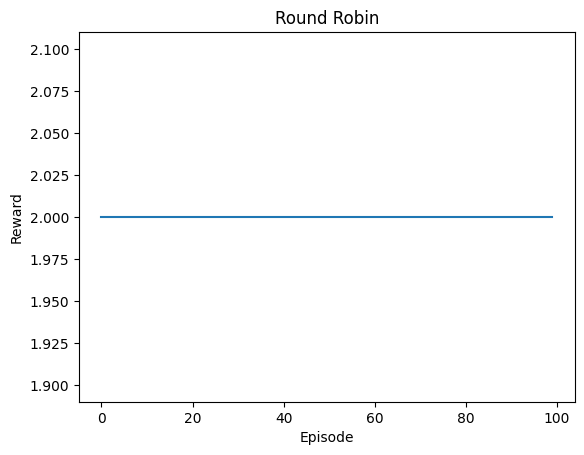

In [3]:
if __name__ == "__main__":
    # Tổng hợp 100 reward của 100 lần chạy episode
    total_reward = []
    for i in range (0, 100):
        env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))
        obs, _ = env.reset()
        x, y = env.position
        if env.dust_grid[x,y] == 1:
            env.total_reward += 1
            env.dust_grid[x,y] = 0
        # env.render()
        
        terminated = False
        truncated = False
        option = "round_robin"
        head, below, left, right = 0, env.m - 1, 0, env.n - 1
        action = 3

        while not terminated and not truncated:
            if option == "random":
                action = robot_policy_1(option, env=env)
            elif option == "round_robin":
                action = robot_policy_2(option, env)
            elif option == "priority_based":
                head, below, left, right, action = robot_policy_3(option, head, below, left, right, action, env)
            obs, reward, terminated, truncated, info = env.step(action)
            # env.render()
            # print(f"Action: {action}, Reward: {reward}, Terminated: {terminated}")
            if terminated or truncated:
                total_reward.append(env.total_reward)
                # print("Episode finished with total reward:", env.total_reward)
                break
    print()
    plt.plot(list(range(0, 100)), total_reward)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Round Robin")
    plt.show()


In [28]:
def save(...):
    pass

SyntaxError: invalid syntax (2685266575.py, line 1)

Evaluation and Analysis

## Part 3: Load Balancing Problem

In [4]:
"""
Load Balancing Environment Simulation

This program simulates a load balancing environment where tasks are distributed among multiple servers. 
Each server has a queue with a limited size, and tasks are processed based on their arrival and the server's availability.

Key Components:
1. Task: Represents a task with a specific processing time.
2. Server: Represents a server that processes tasks. Each server has a queue to hold tasks waiting for processing.
3. LoadBalancingEnv: A custom OpenAI Gym environment that simulates the load balancing scenario. 
     The environment allows agents to decide which server to send a task to, aiming to maximize rewards by minimizing 
     dropped tasks and reducing waiting times.

The goal is to design a load balancing strategy that optimally distributes tasks among servers to maximize efficiency.

Classes:
- Task: Represents a task with a specific processing time.
- Server: Represents a server with a queue of limited size.
- LoadBalancingEnv: Custom Gym environment for the load balancing problem.

Usage:
- The environment can be used to train reinforcement learning agents to learn optimal load balancing strategies.
"""
import csv
import gymnasium as gym
import numpy as np
import random
from collections import deque

class Task:
      """A task with a unique id and required processing time (in time steps)."""

      def __init__(self, task_id: int, processing_time: int):
            self.task_id = task_id  # Unique identifier for tracking
            self.processing_time = processing_time  # Number of steps needed to finish


class Server:
      """
      A server with:
      - one currently running task
      - a waiting queue with finite capacity
      """

      def __init__(self, queue_capacity: int):
            self.queue_capacity = queue_capacity  # Max number of tasks waiting in queue
            self.queue = deque()  # FIFO queue of waiting tasks
            self.current_task = None  # Task being processed right now
            self.remaining_time = 0  # Steps left for current_task

      def run_one_step(self):
            """
            Execute one simulation step on this server.

            Returns:
                  completed_task (Task | None): task completed at this step, if any.
            """
            completed_task = None

            # Process one time unit for currently running task
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.remaining_time > 0:
                  self.remaining_time -= 1
            
            if (self.remaining_time == 0 and self.current_task != None):
                  completed_task = self.current_task
                  self.current_task = None

            # If server becomes idle, immediately pull next task from queue
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.remaining_time == 0 and self.queue_length() > 0:
                  self.current_task = self.queue.popleft()
                  self.remaining_time = self.current_task.processing_time
            
            return completed_task

      def add_task(self, task: Task) -> bool:
            """
            Try to add a task to this server.

            Rules:
            - If server is idle: start processing immediately.
            - Else if queue has room: enqueue task.
            - Else: reject (drop) task.

            Returns:
                  bool: True if accepted, False if dropped.
            """
            # Start immediately if server is free
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.remaining_time == 0 and self.queue_length() == 0:
                  self.current_task = task
                  self.remaining_time = task.processing_time
                  return True

            # Otherwise enqueue if capacity allows
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.queue_length() < self.queue_capacity:
                  self.queue.append(task)
                  return True

            # Queue full -> task dropped
            return False

      def queue_length(self) -> int:
            # Current number of waiting tasks (excluding running task)
            return len(self.queue)

In [ ]:
class LoadBalancingEnv(gym.Env):
      """
      Custom Gym environment for load balancing.

      Action:
            Choose a server index to receive the new incoming task.

      State:
            - each server's remaining processing time and queue length
            - global time step

      Metrics tracked:
            - total_created_tasks
            - accepted_tasks
            - dropped_tasks
            - completed_tasks
            - drop_rate
      """

      metadata = {"render.modes": ["human"]}

      def __init__(self, n_servers: int = 3, queue_capacity: int = 2, seed: int = None):
            super().__init__()
            self.n_servers = n_servers
            self.queue_capacity = queue_capacity
            self.rng = random.Random(seed)  # Local random generator for reproducibility

            # Create server pool
            self.servers = [Server(queue_capacity) for _ in range(n_servers)]
            self.time = 0  # Global simulation step
            self.total_reward = 0.0  # Accumulated reward over episode

            # Task tracking
            self.next_task_id = 0
            self.tasks_created = {}     # task_id -> Task
            self.tasks_completed = set()  # IDs of completed tasks
            self.tasks_dropped = set()  # IDs of dropped tasks
            self.tasks_accepted = set()  # IDs of accepted tasks

            # RL spaces
            # Define action space with n_servers 
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            # Khai báo không gian action cho env là 3 tương ứng với 3 server (0, 1, 2)
            self.action_space = gym.spaces.Discrete(3)

            # Define observation space as a dict containing server states and global time
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            # Khai báo không gian giám sát với 2 thông số là trạng thái của server và tổng thời gian chạy
            self.observation_space = gym.spaces.Dict ({
                  'servers': gym.spaces.Tuple({
                        # Thời gian xử lý còn lại của task hiện tại
                        'remaining_time': gym.spaces.Box (low=1, high=5, shape=(1,), dtype=np.int32),
                        # Độ lớn hàng đợi
                        'queue_length': gym.spaces.Box (low=0, high=queue_capacity, shape=(1,), dtype=np.int32)
                  }),
                  'time': gym.spaces.Box(low=0, high=np.iinfo(np.int32).max, shape=(1,), dtype=np.int32)
            })


      def _new_task(self) -> Task:
            """Create one new incoming task with random processing time [1, 5]."""
            # Create a new task with a unique ID and random processing time between 1 and 5
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            t = Task(self.next_task_id, self.rng.randint(1, 5))
            self.tasks_created[t.task_id] = t
            self.next_task_id += 1
            return t

      def reset(self, *, seed=None, options=None):
            """Reset environment state and all tracking metrics."""
            # Optional reseed to make episode deterministic from this point
            if seed is not None:
                  self.rng.seed(seed)

            # Reinitialize server states, time, and rewards
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.servers = [Server(self.queue_capacity) for _ in range(self.n_servers)]
            self.time = 0
            self.total_reward = 0.0

            # Clear all task statistics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.next_task_id = 0
            self.tasks_created.clear()
            self.tasks_completed.clear()
            self.tasks_dropped.clear()
            self.tasks_accepted.clear()

            # Gymnasium-style reset return: (observation, info)
            return self._get_observation(), {}

      def step(self, action: int):
            """
            Run one simulation step:
            1) Advance all servers by one time step.
            2) Generate one new task.
            3) Route task to selected server.
            4) Compute reward and return transition tuple.
            """
            reward = 0.0

            # 1) Process running tasks on each server
            # For each server, call run_one_step() to advance processing. If a task completes, add to completed set and give a positive reward (+2.0)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for sv in self.servers:
                  task_completed = sv.run_one_step()
                  if (task_completed != None):
                        self.tasks_completed.add(task_completed)
                        reward += 2.0

            # 2) Generate one new incoming task
            new_task = self._new_task()

            # 3) Route task based on action (selected server index)
            # Try to add the new task to the selected server. 
            # If accepted, add to accepted set and give a small reward (+0.5). 
            # If dropped, add to dropped set and give a strong penalty (-5.0).
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            is_true = self.servers[action].add_task(new_task)
            if is_true:
                  self.tasks_accepted.add(new_task)
                  reward += 0.5
            else:
                  self.tasks_dropped.add(new_task)
                  reward -= 5.0
      
            # 4) Add congestion penalty proportional to queue sizes
            # To encourage the agent to balance load and avoid long queues, subtract a small penalty (e.g., -0.5) for each task waiting in any server's queue.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for i in self.servers:
                  queue_len = i.queue_length()
                  if (queue_len > 0):
                        reward += queue_len * (-0.5)
            
            # Update global counters
            self.total_reward += reward
            self.time += 1

            # This environment currently never ends by itself
            terminated = False
            truncated = False
            info = self._get_info()

            return self._get_observation(), reward, terminated, truncated, info

      def _get_observation(self):
            """Build observation dict from current system state."""
            # As a hint to design your observation, we provide the following structure:
            return {
                  "servers": tuple(
                         {
                               "remaining_time": float(server.remaining_time),
                               "queue_length": server.queue_length(),
                         }
                         for server in self.servers
                  ),
                  "time": float(self.time),
            }

      def _get_info(self):
            """Return useful metrics for logging/evaluation."""
            # Compute metrics based on requirements on your lab assignment. Here are some examples:
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            total_created = len(self.tasks_created)
            dropped = len(self.tasks_dropped)
            completed = len(self.tasks_completed)
            accepted = len(self.tasks_accepted)

            # Safe division to avoid divide-by-zero at the beginning
            # Calculate some key performance metrics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            drop_rate = 0.0
            if self.time != 0:
                  drop_rate = dropped / self.time
            #...

            return total_created, dropped, completed, accepted, drop_rate

In [6]:
def load_balancing_policy(option="random", env=None):
      """Simple baseline policy."""
      if option == "random":
            # Uniform random server selection
            return env.action_space.sample()
      # Define other policies based on the option string
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE      
         
      raise ValueError(f"Unsupported policy option: {option}")

In [15]:
if __name__ == "__main__":
      # Create environment and reset initial state
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      obs, info = env.reset()
      metrics = []
      # Run fixed number of simulation steps with random policy
      for step in range(20): # 20 episodes = 20 steps = 20 seconds of simulated time = 20 tasks created
            action = load_balancing_policy(option="random", env=env)
            obs, reward, terminated, truncated, info = env.step(action)
            
            # Print every value you want to track at each step
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            display_obs = ", ".join([f"server {i}: {obs['servers'][i]}" for i in range(env.n_servers)])
            print (f"{display_obs}, time:  {obs['time']}, reward: {reward}, action: {action}")

            # Save metrics to a csv file for later analysis
            metrics.append([display_obs, obs['time'], reward, action])
            save_metrics(metrics)


      # Print summary statistics after simulation ends.
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE
      print ("Total accummulated rewards:", env.total_reward)
      print ("Number of tasks created, dropped, completed and accepted:", info[0], info[1], info[2], info[3])
      print ("Tasks rate dropped:", info[4])


server 0: {'remaining_time': 1.0, 'queue_length': 0}, server 1: {'remaining_time': 0.0, 'queue_length': 0}, server 2: {'remaining_time': 0.0, 'queue_length': 0}, time:  1.0, reward: 0.5, action: 0
server 0: {'remaining_time': 0.0, 'queue_length': 0}, server 1: {'remaining_time': 0.0, 'queue_length': 0}, server 2: {'remaining_time': 1.0, 'queue_length': 0}, time:  2.0, reward: 2.5, action: 2
server 0: {'remaining_time': 0.0, 'queue_length': 0}, server 1: {'remaining_time': 3.0, 'queue_length': 0}, server 2: {'remaining_time': 0.0, 'queue_length': 0}, time:  3.0, reward: 2.5, action: 1
server 0: {'remaining_time': 0.0, 'queue_length': 0}, server 1: {'remaining_time': 2.0, 'queue_length': 0}, server 2: {'remaining_time': 2.0, 'queue_length': 0}, time:  4.0, reward: 0.5, action: 2
server 0: {'remaining_time': 2.0, 'queue_length': 0}, server 1: {'remaining_time': 1.0, 'queue_length': 0}, server 2: {'remaining_time': 1.0, 'queue_length': 0}, time:  5.0, reward: 0.5, action: 0
server 0: {'rem

In [7]:
def save_metrics(metrics):
     with open("metrics.csv", "w", newline="") as file:
          writer = csv.writer(file)
          writer.writerows(metrics)

Evaluation and Analysis

## CONGRATULATIONS TEAM!

Congratulations to the team for completing Part 2,3 of Lab01 - Introduction to Python, Gymnasium and Formulating RL Problem.
Keep up the effort in the next sections.

References: https://gymnasium.farama.org/ 

Suggested additional practice resources: https://gymnasium.farama.org/introduction/create_custom_env/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn
